In [33]:
using Pkg
Pkg.add(url="https://github.com/fernandopenaranda/Optics_in_the_length_gauge")

    Updating git-repo `https://github.com/fernandopenaranda/Optics_in_the_length_gauge`
   Resolving package versions...
  No Changes to `~/Documents/Work/PostdocDonosti/Packages/LMC/Project.toml`
  No Changes to `~/Documents/Work/PostdocDonosti/Packages/LMC/Manifest.toml`


In [3]:
using Pkg
Pkg.activate(dirname(dirname(pwd())))   # activate MyPackage
# Pkg.instantiate()
using Revise
using LMC
using LinearAlgebra
using Optics_in_the_length_gauge
# using CairoMakie

  Activating project at `~/Documents/Work/PostdocDonosti/Packages/LMC`


## Cluster

In [ ]:
# copy from cluster to local
# rsync -avz ferpe@hyperion.sw.ehu.es:/dipc/ferpe/Projects/LMC /Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output

In [4]:
#input self-consistent data (band structures and fillings)
folder = 2281278
simportedvp = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
simportedqah = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")
s = simportedvp

Self_consistent_data([[0.09177345774687988, 0.9082266953889119, 0.09177332560351777, 0.9082265632458201, 0.09177345774707828, 0.9082266953886995, 0.09177332560324447, 0.90822656324608], [0.09511348277570118, 0.9082511047894717, 0.09488496101520044, 0.9082363274508053, 0.09506482891973579, 0.9082485860070545, 0.09488496101520041, 0.9082363274508], [0.09837451965982014, 0.9082578457346432, 0.09819466351798244, 0.9082466677698788, 0.09837451965980154, 0.9082578457346596, 0.09819466212611173, 0.908246668566111], [0.10245915358429471, 0.9083252464279664, 0.10138957737766345, 0.9082700970840478, 0.1014245880034912, 0.9082721917421305, 0.10138957737766344, 0.908270097084047], [0.1063219445813836, 0.908357447941392, 0.10450540358549186, 0.9082591487666652, 0.10465143137966329, 0.9082700749993093, 0.10450540358549182, 0.908259148766665], [0.10919545986212188, 0.9083505993834553, 0.10789113601393205, 0.9082876665175774, 0.10893827608404896, 0.9083380869167671, 0.107891136013932, 0.90828766651757

In [ ]:
l = LMC.readparams(folder)
pimported = ParamsHF(paramsHF(1.05, 1,  1),
    μ = 0,
    nf = l.nf[1],
    λ = l.λ[1],
    M = l.M[1],
    v = l.v[1],
    vp = l.vp[1],
    γ =l.γ[1],
    sigmaz = l.sigmaz[1],
    sigmazlayerz = l.sigmazlayerz[1],
    U1 = l.U1[1],
    U2 = l.U2[1],
    J = 0*l.J[1],
    VP =l.VP[1],
    twovalleystwospins= l.twovalleystwospins[1]);

In [5]:
# HYP Drudes: 
drude_vec = [4619927, 4620201, 4620449, 4620729]
# HYP LMC: [ 4616767, 4617898 , 4618700,  4619343]
lmc_vec = [ 4616767, 4617898 , 4618700,  4619343]

#out put response calculations
drudePID = drude_vec[3]#4619927#4612639 #4604805

drudepath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_data.jld"
drudepresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_presets.jld"
# lmcpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterDATA/LMC/$(lmcPID)_merged_data.jld"
# lmcpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterDATA/LMC/$(lmcPID)_merged_presets.jld"


"/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/4620449_merged_presets.jld"

In [8]:
l = xxx_lmc_presets(ParamsHF(pimported, μ = s.mus[20]), diagm(s.ofmats[20]), T = 1, evals = 19);

Planar_σijk_presets_orbital{LMC.var"#h#181"{ParamsHF, Matrix{Float64}}, LMC.var"#dh#184"{LMC.var"#dhy#183"{ParamsHF, Matrix{Float64}}, LMC.var"#dhx#182"{ParamsHF, Matrix{Float64}}}, LMC.var"#dhxx#185"{Tuple{Int64, Int64}}, LMC.var"#rzmat#186"{ParamsHF, Matrix{Float64}}}
  a0: Float64 2.46
  dirJ: Symbol x
  dirE: Symbol x
  dirB: Symbol x
  h: h (function of type LMC.var"#h#181"{ParamsHF, Matrix{Float64}})
  nabla_h: dh (function of type LMC.var"#dh#184"{LMC.var"#dhy#183"{ParamsHF, Matrix{Float64}}, LMC.var"#dhx#182"{ParamsHF, Matrix{Float64}}})
  nabla_nabla_h: dhxx (function of type LMC.var"#dhxx#185"{Tuple{Int64, Int64}})
  rz: rzmat (function of type LMC.var"#rzmat#186"{ParamsHF, Matrix{Float64}})
  τ: Float64 2.0e-13
  T: Float64 1.0
  computation: Transport_computation_presets
  berry_contribution: Bool true
  omm_contribution: Bool true
  fermi_surface: Bool false
  with_shift: Bool false


In [9]:

@code_warntype linear_magneto_conductivity_orbital(
        xxx_lmc_presets(ParamsHF(pimported, μ = s.mus[20]), 
         diagm(s.ofmats[20]), T = 1, evals = 10)) 

MethodInstance for Optics_in_the_length_gauge.linear_magneto_conductivity_orbital(::Planar_σijk_presets_orbital{LMC.var"#h#181"{ParamsHF, Matrix{Float64}}, LMC.var"#dh#184"{LMC.var"#dhy#183"{ParamsHF, Matrix{Float64}}, LMC.var"#dhx#182"{ParamsHF, Matrix{Float64}}}, LMC.var"#dhxx#185"{Tuple{Int64, Int64}}, LMC.var"#rzmat#186"{ParamsHF, Matrix{Float64}}})
  from linear_magneto_conductivity_orbital(params::Planar_σijk_presets_orbital) @ Optics_in_the_length_gauge ~/.julia/packages/Optics_in_the_length_gauge/JB7h8/src/linear_magneto_transport_orbital.jl:35
Arguments
  #self#::Core.Const(Optics_in_the_length_gauge.linear_magneto_conductivity_orbital)
  params::Planar_σijk_presets_orbital{LMC.var"#h#181"{ParamsHF, Matrix{Float64}}, LMC.var"#dh#184"{LMC.var"#dhy#183"{ParamsHF, Matrix{Float64}}, LMC.var"#dhx#182"{ParamsHF, Matrix{Float64}}}, LMC.var"#dhxx#185"{Tuple{Int64, Int64}}, LMC.var"#rzmat#186"{ParamsHF, Matrix{Float64}}}
Body::Float64
1 ─ %1  = Base.getproperty(params, :a0)::Float64
│ 

## Calculations

In [32]:
using Profile
us
e = 1000
@pprof linear_magneto_conductivity_orbital(
    xxx_lmc_presets(ParamsHF(pimported, μ = s.mus[20]), 
        diagm(s.ofmats[20]), T = 1.0, evals = e)) 
        println("evals: ", e," val: ", val)

evals: 1000 val: 0.0011113353845561135


In [29]:
@pprof linear_magneto_conductivity_orbital(
    xxx_lmc_presets(ParamsHF(pimported, μ = s.mus[20]), 
        diagm(s.ofmats[20]), T = 1.0, evals = 1000))

"profile.pb.gz"

In [299]:
evallist = [2,10, 100, 1000, 5000, 10000, 20000, 50000]
for e in evallist
        val = linear_magneto_conductivity_orbital(
        xxx_lmc_presets(ParamsHF(pimported, μ = s.mus[20]), 
         diagm(s.ofmats[20]), T = 1, evals = e)) 
         println("evals: ", e," val: ", val)
end

evals: 2 val: -0.0002518229622575495
evals: 10 val: -0.0002518229622575495
evals: 100 val: -0.0010669898755006392
evals: 1000 val: 0.0011113353845561135
evals: 5000 val: 0.018710434627927576
evals: 10000 val: 0.02071746498775495
evals: 20000 val: 0.024316852188479475
evals: 50000 val: 0.027596921583580958


In [285]:
@time vorbs = lmc_orb_sweep(folder, "vp", evals = 100, T = 5)

progress: 0.1 |  val: 0.020097440001143614
progress: 0.2 |  val: -0.009733368119800362
progress: 0.3 |  val: 2.4779568210724197e-5
progress: 0.4 |  val: 0.009334725196453283
progress: 0.5 |  val: 0.003144744334475241
progress: 0.6 |  val: 0.0038041470131487958
progress: 0.7 |  val: 0.0031062630755299657
progress: 0.8 |  val: 0.0007639592256844363
progress: 0.9 |  val: 0.004263099768447379
progress: 1.0 |  val: -0.006724570707088454
1253.827796 seconds (186.87 M allocations: 950.333 GiB, 5.88% gc time, 0.00% compilation time: 100% of which was recompilation)


([0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[0.020097440001143614, -0.009733368119800362, 2.4779568210724197e-5, 0.009334725196453283, 0.003144744334475241, 0.0038041470131487958, 0.0031062630755299657, 0.0007639592256844363, 0.004263099768447379, -0.006724570707088454])

In [293]:
1253/60*10/60

3.480555555555555

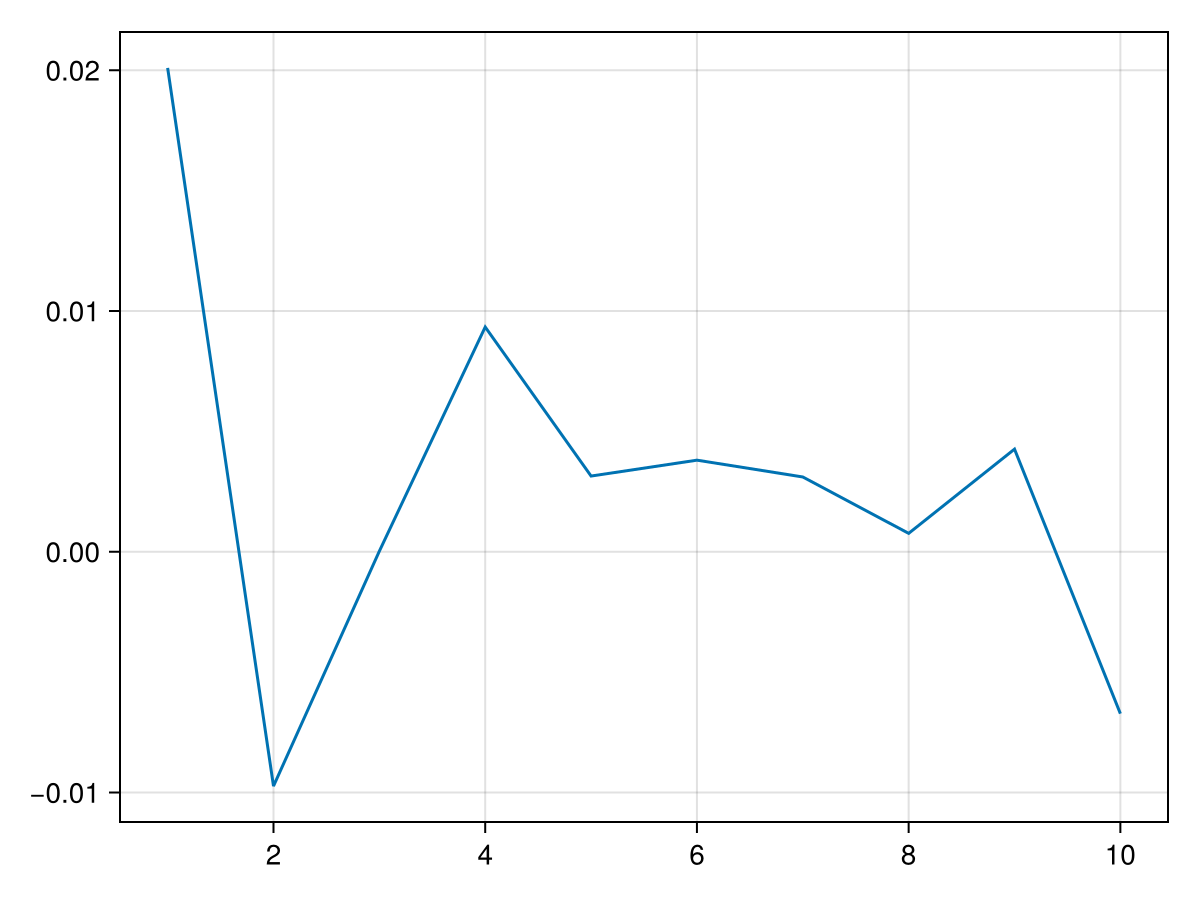

In [290]:
fig = Figure(); ax = Axis(fig[1,1]);
 lines!(ax, [v for v in vorbs[2]], label = "5000")
fig

In [ ]:
vspins = lmc_spin_sweep(folder, "vp", evals = 2)

In [69]:
vdrude = drude_sweep(folder, "vp", evals = 20000, T=10)

progress: 0.005 |  val: 145.80328302161308
progress: 0.01 |  val: 217.4208116189097
progress: 0.015 |  val: 173.53477326358566
progress: 0.02 |  val: 175.18887772750892
progress: 0.025 |  val: 195.86999322831977
progress: 0.03 |  val: 180.32562412733435
progress: 0.035 |  val: 162.4630399298558
progress: 0.04 |  val: 187.44194956849398
progress: 0.045 |  val: 186.07344399765188
progress: 0.05 |  val: 160.4703125096659
progress: 0.055 |  val: 145.48212983850135
progress: 0.06 |  val: 156.38965716449482
progress: 0.065 |  val: 140.7415248520458
progress: 0.07 |  val: 145.16808181337785
progress: 0.075 |  val: 151.406265471841
progress: 0.08 |  val: 89.52535565292199
progress: 0.085 |  val: 75.68712913292521
progress: 0.09 |  val: 77.28696992508888
progress: 0.095 |  val: 84.06277745801349
progress: 0.1 |  val: 70.2201329167506
progress: 0.105 |  val: 76.39739215954023
progress: 0.11 |  val: 75.87391475314297
progress: 0.115 |  val: 78.86483056831374
progress: 0.12 |  val: 77.663892443980

([0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[145.80328302161308, 217.4208116189097, 173.53477326358566, 175.18887772750892, 195.86999322831977, 180.32562412733435, 162.4630399298558, 187.44194956849398, 186.07344399765188, 160.4703125096659  …  4.281157719694664, 5.196103138712259, 3.4184251006230912, 2.6675372120765846, 2.180976399923536, 1.7732354192258875, 1.370616498981697, 1.479948705407227, 1.2814811499012808, 1.6325092239141226])

## Plots

In [203]:
using CairoMakie, LaTeXStrings, JLD2, Colors

In [235]:

function lat_tbg_figure( drudepresetpath, drudepath, lmcpresetpath, lmcpath, folder = 2281278; fontsize = 14)
    with_theme(merge(theme_latexfonts(), Theme(fontsize = fontsize))) do #
        tbg_figure( drudepresetpath, drudepath, lmcpresetpath, lmcpath, folder; fontsize = fontsize)   
    end
end

function tbg_figure(drudepresetpath, drudepath, lmcpresetpath, lmcpath, folder; fontsize = 12)
    figtbg = Figure(size = (600, 600))
    ax1 = Axis(figtbg[1,1], xlabel = "ν", ylabel = L"$|\langle \tau_z \rangle_\text{f}|$", xlabelsize = fontsize +2, ylabelsize = fontsize +2)
    ax2 = Axis(figtbg[2:3,1], xlabel = "ν", ylabel = L"$\sigma_{xxx}^{(S,1)}/\sigma_{xx}\text{ [1/T]}$", xlabelsize = fontsize +2, ylabelsize = fontsize +2)
    hidexdecorations!(ax1, grid = false)

    simportedvp = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
    simportedqah = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")
    t1 = tauz(simportedvp)
    t2 = tauz(simportedqah)
    fig = Figure()
    
    col = parse(Colorant, "#FF34FFFF")
    lines!(ax1, simportedvp.ns, t1, label =  L"$\text{VP}" , color = col)
    lines!(ax1, simportedvp.ns, t2, label =  L"$\text{VH/SVH}$", color = :black)
    ylims!(ax, -0.01, 2)
    axislegend(ax1, position = :lt)

    #_________________________________________#_________________________________________
    νs, vals = aux_plot_tbg_obs(drudepresetpath, drudepath)
    # ylims!(ax2, -0.05,0.05)
    lines!(ax2, [ν for ν in νs], [obs for obs in vals])
    
    figtbg
end


function tauz(s::Self_consistent_data)
    taus = zeros(Float64,length(s.ofmats))
    for i in 1:length(s.ofmats)
        taus[i] = abs(sum(s.ofmats[i] .* [1, 1, -1, -1, 1, 1, -1, -1]))
    end
    taus
end


tauz (generic function with 1 method)

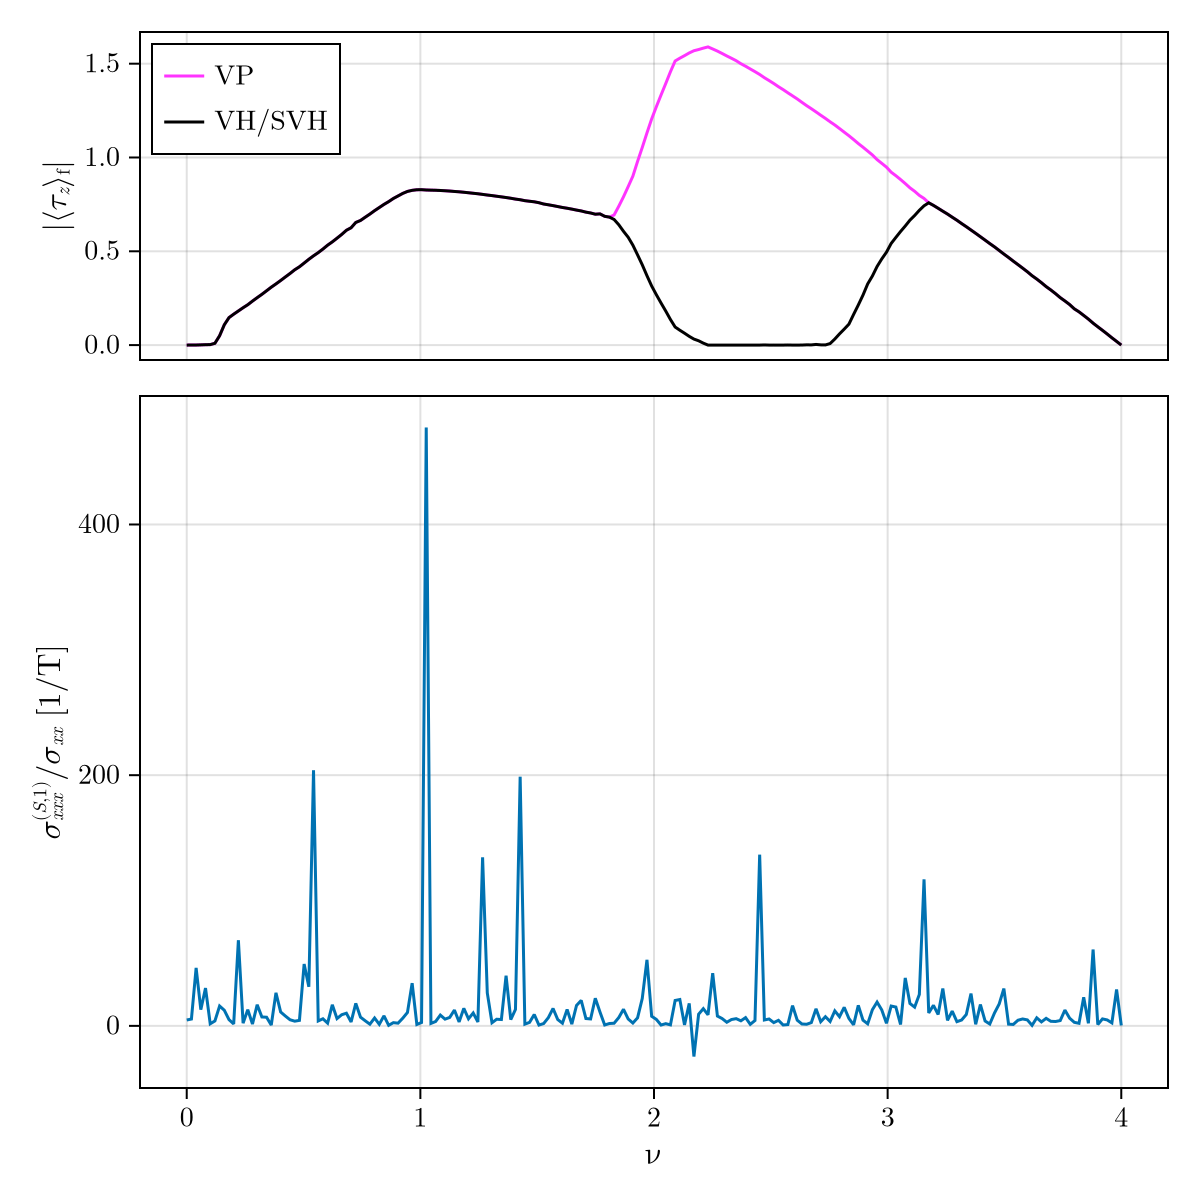

In [236]:
lat_tbg_figure(drudepresetpath, drudepath, drudepresetpath, drudepath)

In [197]:
νs, vals = aux_plot_tbg_obs(drudepresetpath, drudepath)

(Any[0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[0.0015142086307367718, 4.03606353679876e-5, 3.864525560209984e-5, 1.8313918573035783e-5, 9.971173773396586e-5, -0.00010075461187297188, -0.00029582992643522617, -0.1623841401870363, 0.0012419331741299756, -6.771681464843659e-5  …  8.005886853046762e-6, -0.00011735013662332342, -0.0322024576181838, 0.0003807314029990155, 0.00012641595399805688, 2.4413042592110023e-5, -0.0009188762107061934, 5.191696913022093e-6, 0.0001340812562989715, -3.0349550527326143e-5])

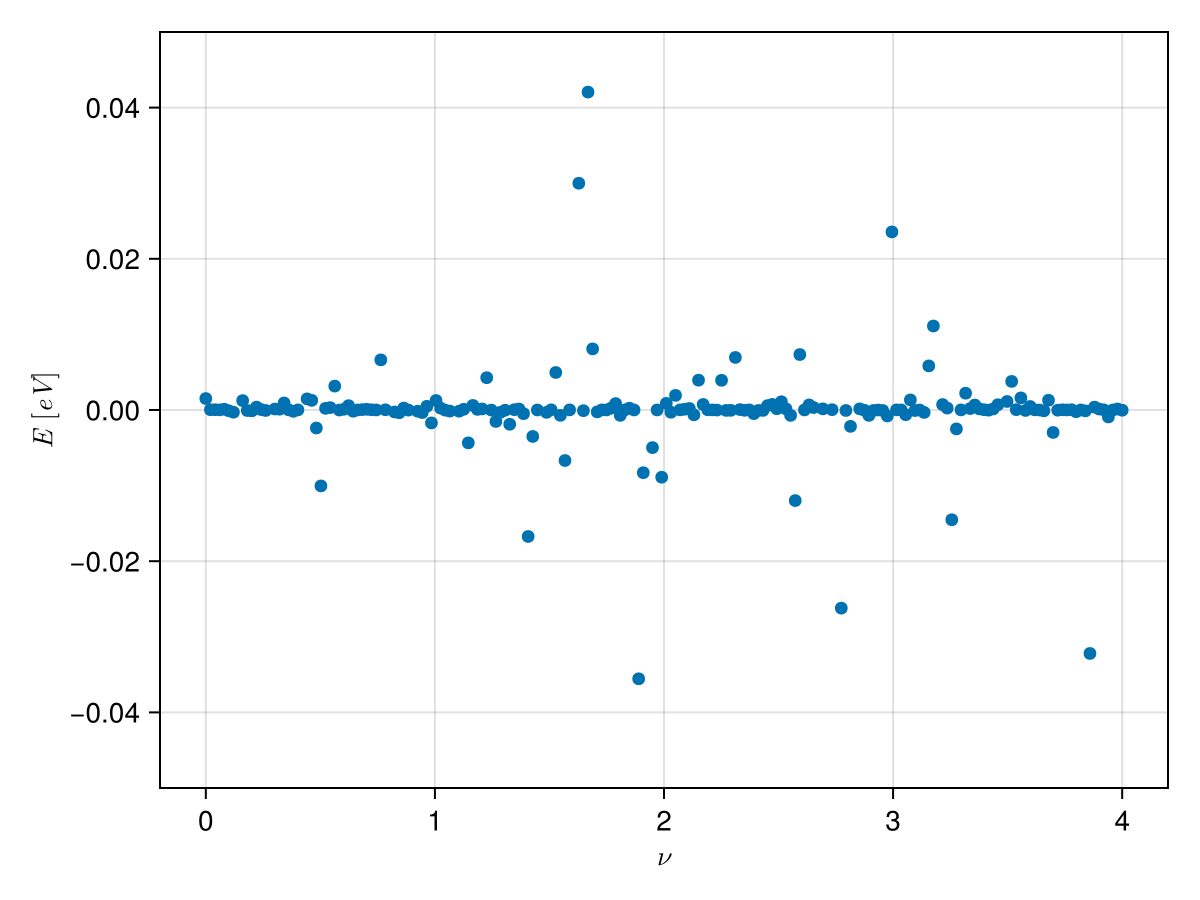

In [225]:

fig = Figure()
ax = Axis(fig[1,1], xlabel = L"$\nu$", ylabel = L"$E\text{ }[eV]$")
ylims!(ax, -0.05,0.05)
scatter!(ax, [ν for ν in νs], [obs for obs in vals])
fig


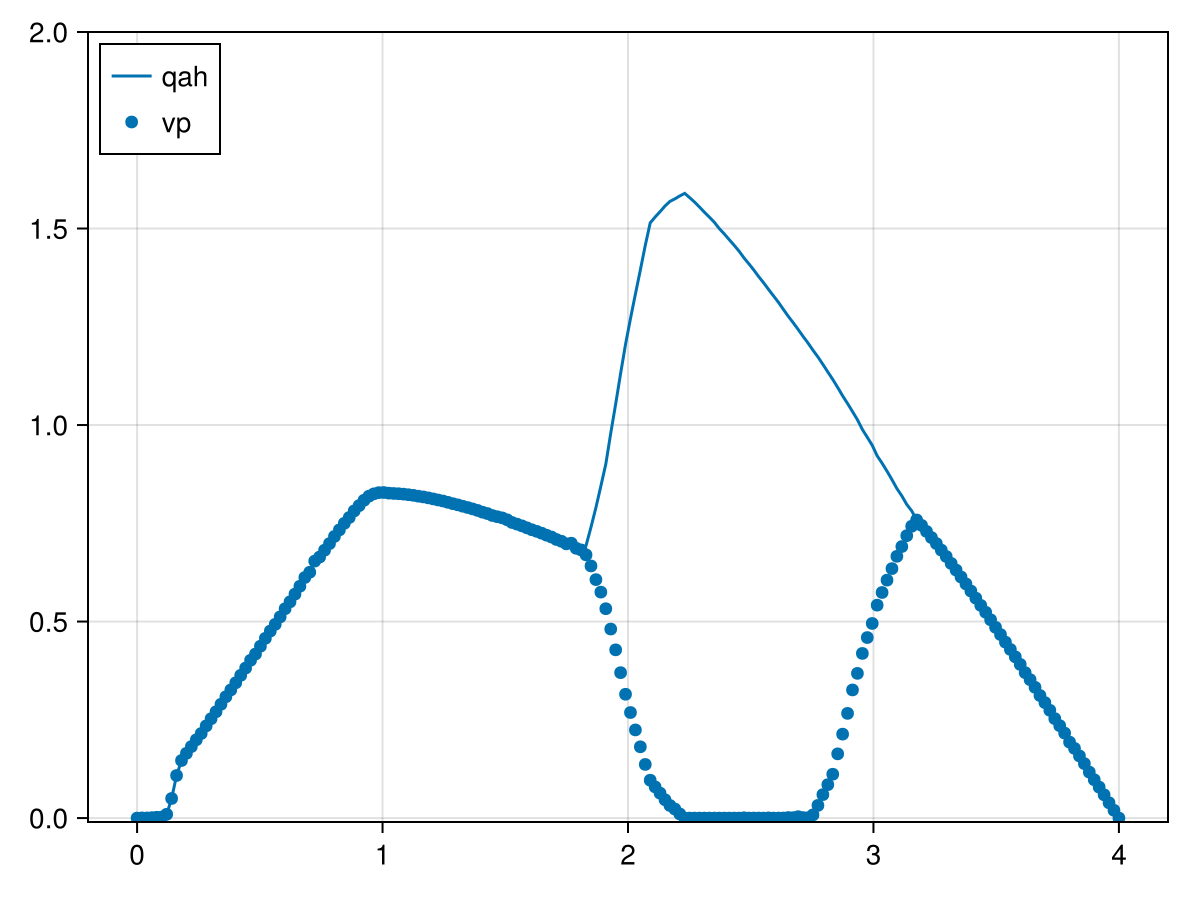

In [172]:
#input self-consistent data (band structures and fillings)
folder = 2281278
simportedvp = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
simportedqah = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")

function tauz(s::Self_consistent_data)
    taus = zeros(Float64,length(s.ofmats))
    for i in 1:length(s.ofmats)
        taus[i] = abs(sum(s.ofmats[i] .* [1, 1, -1, -1, 1, 1, -1, -1]))
    end
    taus
end
t1 = tauz(simportedvp)
t2 = tauz(simportedqah)
fig = Figure()
ax = Axis(fig[1,1]) 
lines!(ax, simportedvp.ns, t1, label = "qah")
scatter!(ax, simportedvp.ns, t2, label = "vp")
ylims!(ax, -0.01, 2)
axislegend(ax, position = :lt)
fig

## Tests

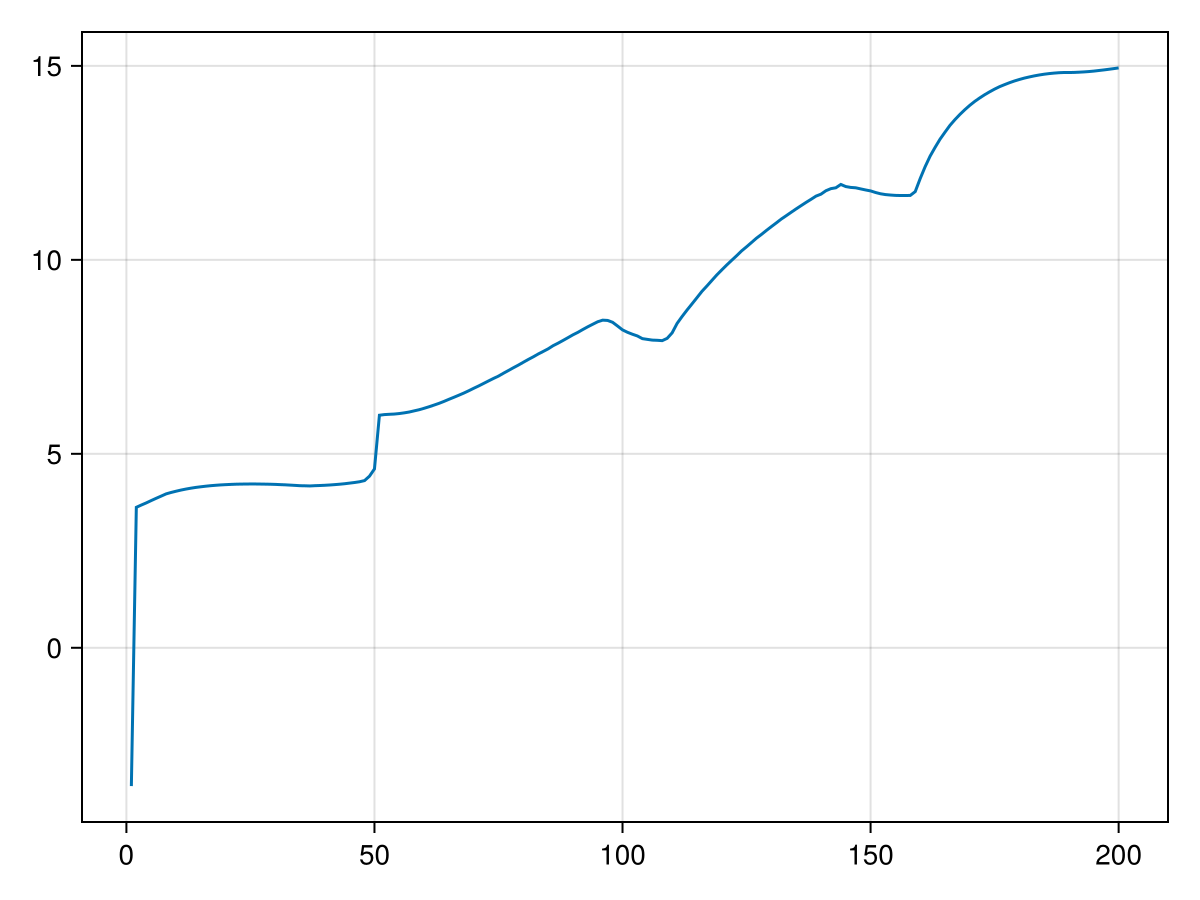

In [21]:
fig = Figure()
ax = Axis(fig[1,1])
lines!(ax, simportedvp.mus)
fig

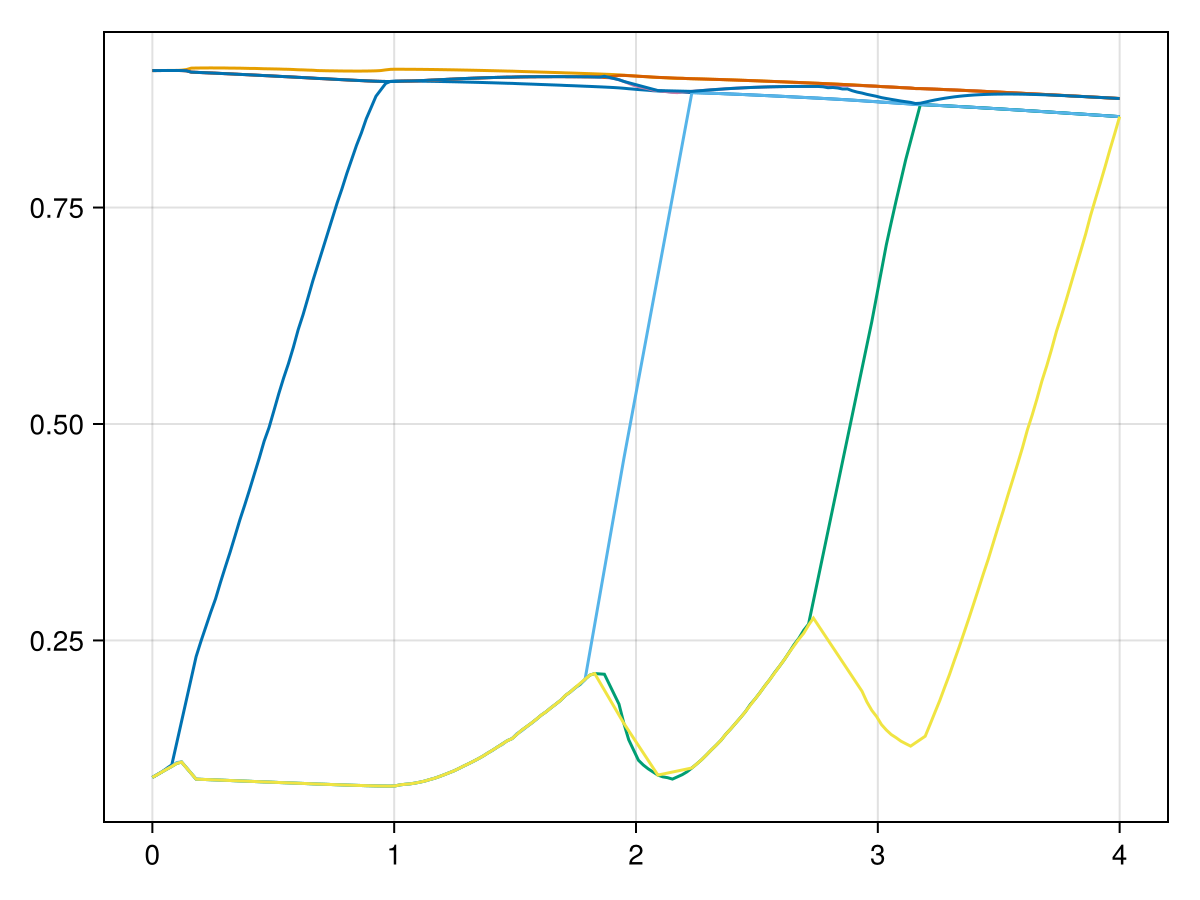

In [114]:
fig = Figure()
ax = Axis(fig[1,1])
s = simportedvp

[lines!(ax, s.ns, intnss[it]) for it in 1:8]
fig
# lines!(ax, simportedqah.ofmats[8])